<div style="background:#0F172A; padding:40px 50px; border-radius:0; margin-bottom:0;">
  <h1 style="color:#FFFFFF; font-size:2.2em; margin:0; font-weight:800; letter-spacing:2px;">
    🚢 CLASIFICACIÓN CON MACHINE LEARNING
  </h1>
  <h2 style="color:#0284C7; font-size:1.2em; margin:12px 0 6px 0; font-weight:400;">
    Caso Práctico: Sobrevivientes del Titanic
  </h2>
  <div style="height:3px; background:#0284C7; width:120px; margin:16px 0;"></div>
  <p style="color:#94A3B8; font-size:0.95em; margin:0;">
    Ejercicio introductorio · Machine Learning · Clasificación Binaria
  </p>
</div>
<div style="background:#1E293B; padding:18px 50px; margin-bottom:30px;">
  <p style="color:#E2E8F0; margin:0; font-size:0.93em;">
    <strong style="color:#0284C7;">Objetivo:</strong> Predecir si un pasajero sobrevivió al hundimiento del Titanic usando sus características personales.<br>
    <strong style="color:#0284C7;">Cubriremos:</strong> Exploración de datos · Limpieza · Feature Engineering · Comparación de 6 algoritmos · Interpretación de resultados
  </p>
</div>

---
## 📦 Sección 0 — Importación de Librerías

> **Buena práctica:** Siempre importar todas las librerías al inicio del notebook. Así cualquier persona que lo abra sabe qué dependencias necesita de un solo vistazo.

In [ ]:
# ── Manipulación de datos ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Preprocesamiento ───────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ── Algoritmos de clasificación ────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ── Métricas de evaluación ─────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

# ── Configuración global ───────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette("Blues_r")

RANDOM_STATE = 42   # Semilla para reproducibilidad
print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


---
## 📂 Sección 1 — Carga y Primera Inspección de Datos

### El Dataset: Titanic 🚢

El RMS Titanic se hundió el 15 de abril de 1912. De los ~2.224 pasajeros a bordo, solo ~710 sobrevivieron.

**¿Cuál es la pregunta de negocio?**  
> *Dado lo que sabemos de un pasajero (clase, sexo, edad, tarifa...) ¿podemos predecir si sobrevivió?*

**Variable objetivo:** `Survived` → 0 = No sobrevivió, 1 = Sobrevivió

> **💡 Tip:** Siempre tenemos dos conjuntos:
> - **Train** (`train.csv`): tiene la respuesta (`Survived`). Aquí entrenamos y evaluamos.  
> - **Test** (`test.csv`): NO tiene `Survived`. Es para predicciones finales (como si fuera producción).

In [ ]:
# Cargar los datos
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Train: {train.shape[0]} filas × {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]} filas × {test.shape[1]} columnas")
print()
print("Primeras 5 filas del train:")
train.head()

Train: 891 filas × 12 columnas
Test:  418 filas × 11 columnas

Primeras 5 filas del train:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Descripción de cada columna
descripcion = {
    'PassengerId': 'ID único del pasajero',
    'Survived':    '🎯 TARGET: 0 = No sobrevivió, 1 = Sobrevivió',
    'Pclass':      'Clase del boleto (1=Primera, 2=Segunda, 3=Tercera)',
    'Name':        'Nombre completo',
    'Sex':         'Sexo (male/female)',
    'Age':         'Edad en años',
    'SibSp':       'Nº de hermanos/cónyuge a bordo',
    'Parch':       'Nº de padres/hijos a bordo',
    'Ticket':      'Número de ticket',
    'Fare':        'Tarifa pagada (libras)',
    'Cabin':       'Número de camarote',
    'Embarked':    'Puerto de embarque (C=Cherburgo, Q=Queenstown, S=Southampton)',
}
print("📋 DICCIONARIO DE VARIABLES")
print("─" * 55)
for col, desc in descripcion.items():
    print(f"  {col:<14} → {desc}")

📋 DICCIONARIO DE VARIABLES
───────────────────────────────────────────────────────
  PassengerId    → ID único del pasajero
  Survived       → 🎯 TARGET: 0 = No sobrevivió, 1 = Sobrevivió
  Pclass         → Clase del boleto (1=Primera, 2=Segunda, 3=Tercera)
  Name           → Nombre completo
  Sex            → Sexo (male/female)
  Age            → Edad en años
  SibSp          → Nº de hermanos/cónyuge a bordo
  Parch          → Nº de padres/hijos a bordo
  Ticket         → Número de ticket
  Fare           → Tarifa pagada (libras)
  Cabin          → Número de camarote
  Embarked       → Puerto de embarque (C=Cherburgo, Q=Queenstown, S=Southampton)


In [ ]:
# Resumen estadístico
print("📊 ESTADÍSTICAS DESCRIPTIVAS — Variables Numéricas")
train.describe().round(2)

📊 ESTADÍSTICAS DESCRIPTIVAS — Variables Numéricas


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [ ]:
# Valores nulos — un paso crítico
print("🔍 VALORES NULOS POR COLUMNA")
print("─" * 40)
nulls = train.isnull().sum()
pct   = (nulls / len(train) * 100).round(1)
summary = pd.DataFrame({'Nulos': nulls, '% Missing': pct})
summary = summary[summary['Nulos'] > 0].sort_values('% Missing', ascending=False)
print(summary.to_string())
print()
print("⚠️  Cabin tiene 77% de nulos → la descartaremos")
print("⚠️  Age tiene 20% de nulos  → imputaremos con la mediana")
print("⚠️  Embarked tiene 2 nulos  → imputaremos con la moda")

🔍 VALORES NULOS POR COLUMNA
────────────────────────────────────────
          Nulos  % Missing
Cabin       687       77.1
Age         177       19.9
Embarked      2        0.2

⚠️  Cabin tiene 77% de nulos → la descartaremos
⚠️  Age tiene 20% de nulos  → imputaremos con la mediana
⚠️  Embarked tiene 2 nulos  → imputaremos con la moda


---
## 📊 Sección 2 — Análisis Exploratorio de Datos (EDA)

> **EDA = Entender los datos antes de modelar.**  
> Nunca entrenes un modelo sin conocer tus datos. El EDA te dice qué features son relevantes, dónde hay problemas y qué esperar del modelo.

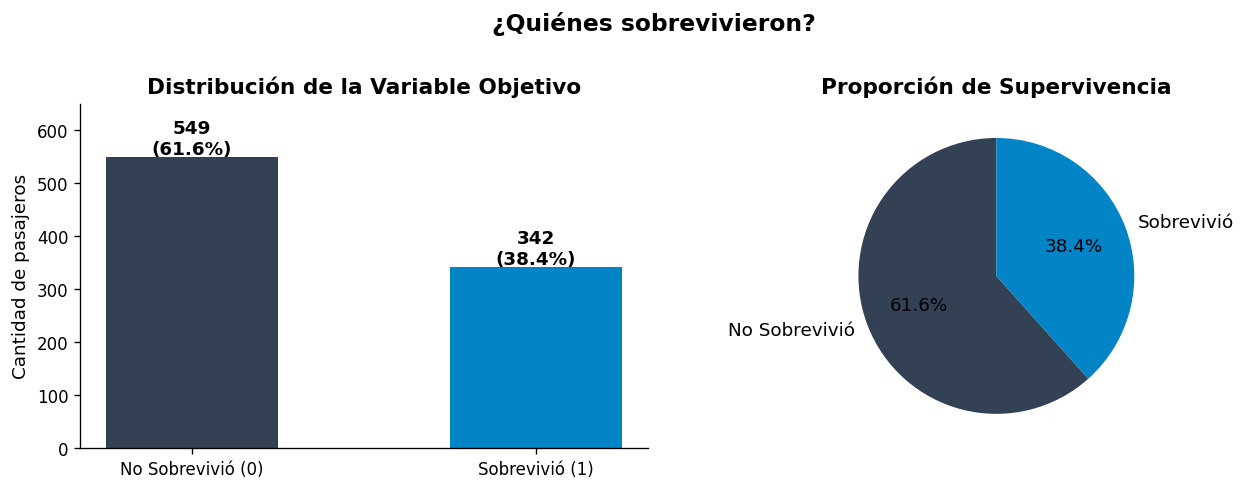


📌 El dataset está moderadamente desbalanceado: 549 no sobrevivieron vs 342 que sí.
   Ratio: 1.61:1   → Usaremos F1-Score además de Accuracy.


In [ ]:
# ── Distribución del TARGET ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gráfico de barras
counts = train['Survived'].value_counts()
colors = ['#334155', '#0284C7']
bars = axes[0].bar(['No Sobrevivió (0)', 'Sobrevivió (1)'], counts.values, color=colors, width=0.5)
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Cantidad de pasajeros')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/len(train)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 650)

# Pie chart
axes[1].pie(counts.values, labels=['No Sobrevivió', 'Sobrevivió'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Proporción de Supervivencia', fontweight='bold')

plt.suptitle('¿Quiénes sobrevivieron?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n📌 El dataset está moderadamente desbalanceado: {counts[0]} no sobrevivieron vs {counts[1]} que sí.")
print(f"   Ratio: {counts[0]/counts[1]:.2f}:1   → Usaremos F1-Score además de Accuracy.")

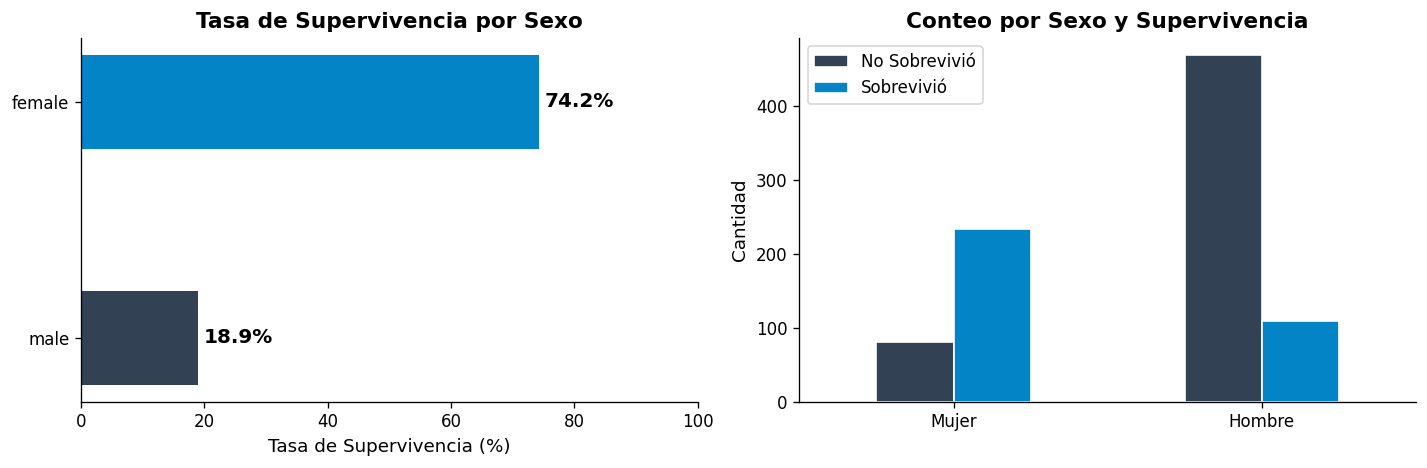

📌 HALLAZGO CLAVE: El sexo es un predictor muy fuerte.
   Mujeres: 74.2% sobrevivieron
   Hombres: 18.9% sobrevivieron


In [ ]:
# ── Supervivencia por Sexo ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tasa de supervivencia
surv_sex = train.groupby('Sex')['Survived'].mean().sort_values()
colors = ['#0284C7', '#334155']
bars = axes[0].barh(surv_sex.index, surv_sex.values * 100, color=colors[::-1], height=0.4)
axes[0].set_xlabel('Tasa de Supervivencia (%)')
axes[0].set_title('Tasa de Supervivencia por Sexo', fontweight='bold')
axes[0].set_xlim(0, 100)
for bar, val in zip(bars, surv_sex.values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontweight='bold', fontsize=12)

# Conteos
counts_sex = train.groupby(['Sex', 'Survived']).size().unstack()
counts_sex.plot(kind='bar', ax=axes[1], color=['#334155', '#0284C7'],
                width=0.5, edgecolor='white')
axes[1].set_title('Conteo por Sexo y Supervivencia', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Mujer', 'Hombre'], rotation=0)
axes[1].legend(['No Sobrevivió', 'Sobrevivió'], title='')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print("📌 HALLAZGO CLAVE: El sexo es un predictor muy fuerte.")
print(f"   Mujeres: {train[train.Sex=='female']['Survived'].mean()*100:.1f}% sobrevivieron")
print(f"   Hombres: {train[train.Sex=='male']['Survived'].mean()*100:.1f}% sobrevivieron")

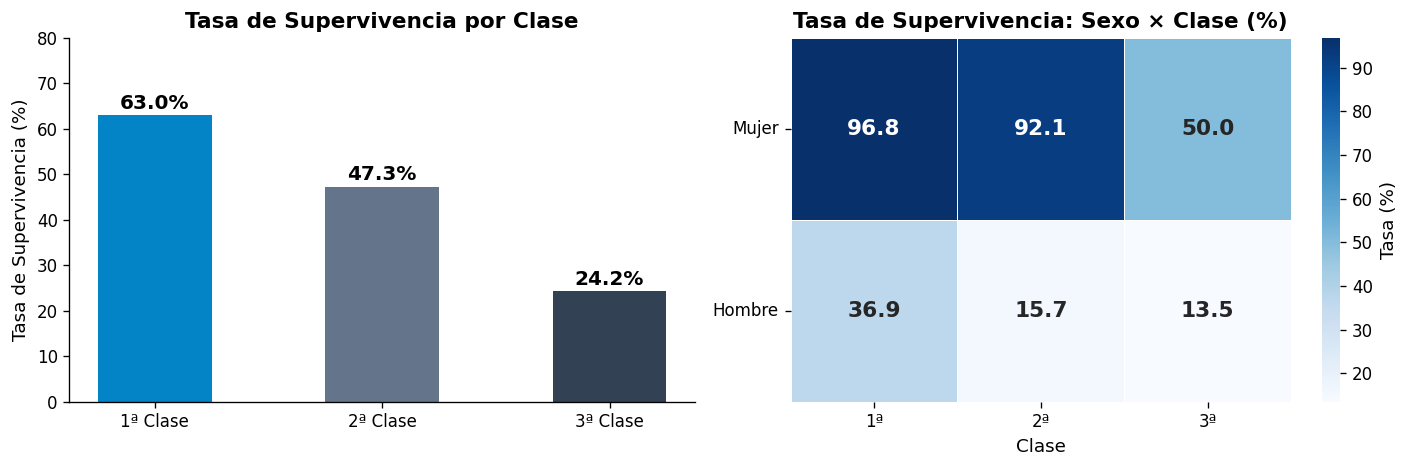

📌 Patrón 'Mujeres y niños primero' se confirma en los datos.
   Las mujeres de 1ª clase tuvieron la mayor tasa de supervivencia (96.8%)


In [ ]:
# ── Supervivencia por Clase y Sexo ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Por clase
surv_class = train.groupby('Pclass')['Survived'].mean()
colors_class = ['#0284C7', '#64748B', '#334155']
bars = axes[0].bar(['1ª Clase', '2ª Clase', '3ª Clase'],
                   surv_class.values * 100, color=colors_class, width=0.5)
axes[0].set_title('Tasa de Supervivencia por Clase', fontweight='bold')
axes[0].set_ylabel('Tasa de Supervivencia (%)')
axes[0].set_ylim(0, 80)
for bar, val in zip(bars, surv_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Heatmap: Clase × Sexo
pivot = train.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
sns.heatmap(pivot * 100, ax=axes[1], annot=True, fmt='.1f',
            cmap='Blues', linewidths=0.5, cbar_kws={'label': 'Tasa (%)'},
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Tasa de Supervivencia: Sexo × Clase (%)', fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('')
axes[1].set_yticklabels(['Mujer', 'Hombre'], rotation=0)
axes[1].set_xticklabels(['1ª', '2ª', '3ª'], rotation=0)

plt.tight_layout()
plt.show()

print("📌 Patrón 'Mujeres y niños primero' se confirma en los datos.")
print("   Las mujeres de 1ª clase tuvieron la mayor tasa de supervivencia (96.8%)")

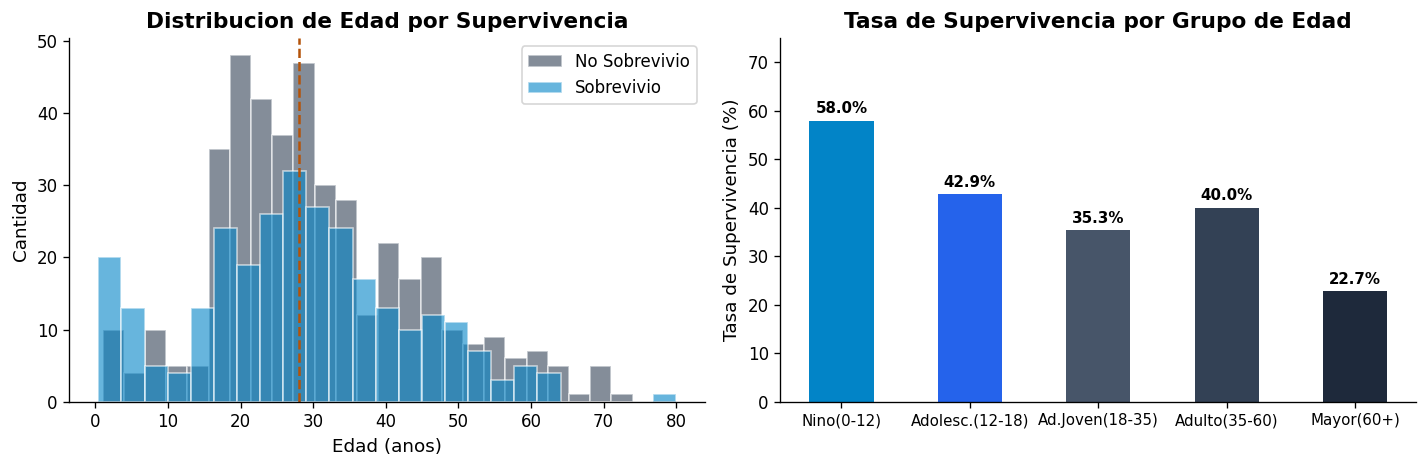

Hallazgo: Los ninos pequenos tuvieron prioridad de evacuacion.


In [ ]:
# ── Distribución de Edad ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma por supervivencia
for survived, label, color in [(0, 'No Sobrevivio', '#334155'), (1, 'Sobrevivio', '#0284C7')]:
    subset = train[train['Survived'] == survived]['Age'].dropna()
    axes[0].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0].set_title('Distribucion de Edad por Supervivencia', fontweight='bold')
axes[0].set_xlabel('Edad (anos)')
axes[0].set_ylabel('Cantidad')
axes[0].legend()
axes[0].axvline(train['Age'].median(), color='#B45309', linestyle='--', linewidth=1.5)

# Supervivencia por grupo de edad
labels_edad = ['Nino(0-12)', 'Adolesc.(12-18)', 'Ad.Joven(18-35)', 'Adulto(35-60)', 'Mayor(60+)']
train['AgeGroup'] = pd.cut(
    train['Age'].fillna(train['Age'].median()),
    bins=[0, 12, 18, 35, 60, 100],
    labels=labels_edad
)
surv_age = train.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
colors_age = ['#0284C7', '#2563EB', '#475569', '#334155', '#1E293B']
axes[1].bar(surv_age.index, surv_age.values, color=colors_age, width=0.5)
axes[1].set_title('Tasa de Supervivencia por Grupo de Edad', fontweight='bold')
axes[1].set_ylabel('Tasa de Supervivencia (%)')
axes[1].set_ylim(0, 75)
axes[1].tick_params(axis='x', labelsize=9)
for i, val in enumerate(surv_age.values):
    axes[1].text(i, val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

train.drop('AgeGroup', axis=1, inplace=True)
print("Hallazgo: Los ninos pequenos tuvieron prioridad de evacuacion.")

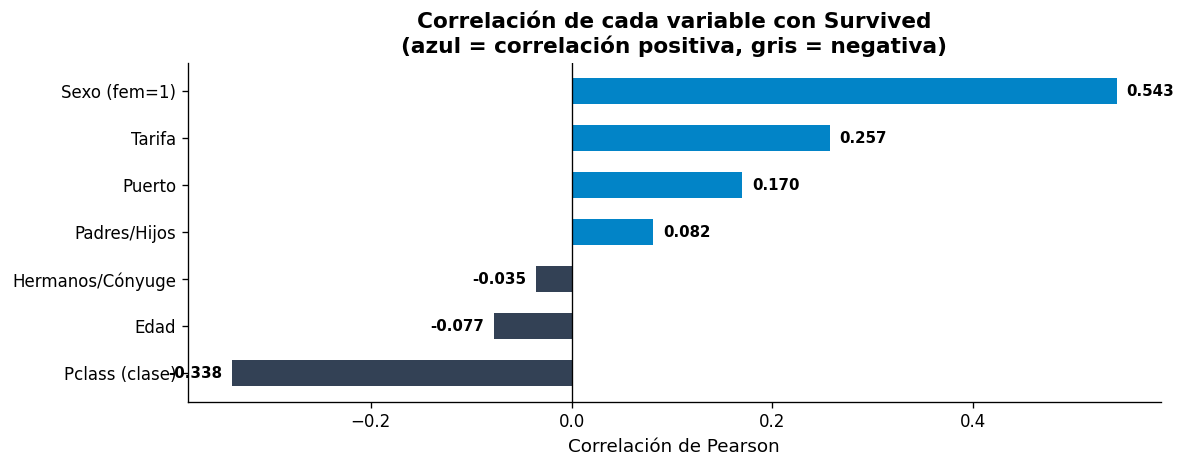

📌 Las variables más correlacionadas con Survived son:
   ✦ Sexo (femenino)  → r = 0.543  (correlación positiva fuerte)
   ✦ Clase (Pclass)   → r = -0.338 (correlación negativa: clase alta = más supervivencia)
   ✦ Tarifa (Fare)    → r = 0.257  (correlación positiva: boletos caros = más supervivencia)


In [ ]:
# ── Correlación con la variable objetivo ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

# Codificar sex temporalmente para la correlación
temp = train.copy()
temp['Sex_encoded'] = (temp['Sex'] == 'female').astype(int)
temp['Embarked_encoded'] = temp['Embarked'].map({'S': 0, 'Q': 1, 'C': 2})

num_cols = ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_encoded']
corr = temp[num_cols + ['Survived']].corr()['Survived'].drop('Survived').sort_values()

colors = ['#0284C7' if v > 0 else '#334155' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors, height=0.55)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable con Survived\n(azul = correlación positiva, gris = negativa)',
             fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
labels = {
    'Pclass': 'Pclass (clase)', 'Sex_encoded': 'Sexo (fem=1)',
    'Age': 'Edad', 'SibSp': 'Hermanos/Cónyuge',
    'Parch': 'Padres/Hijos', 'Fare': 'Tarifa', 'Embarked_encoded': 'Puerto'
}
ax.set_yticklabels([labels.get(c, c) for c in corr.index])
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("📌 Las variables más correlacionadas con Survived son:")
print(f"   ✦ Sexo (femenino)  → r = {corr['Sex_encoded']:.3f}  (correlación positiva fuerte)")
print(f"   ✦ Clase (Pclass)   → r = {corr['Pclass']:.3f} (correlación negativa: clase alta = más supervivencia)")
print(f"   ✦ Tarifa (Fare)    → r = {corr['Fare']:.3f}  (correlación positiva: boletos caros = más supervivencia)")

---
## 🔧 Sección 3 — Limpieza de Datos y Feature Engineering

> **Regla de oro:** Aplicar exactamente el mismo pipeline de transformaciones a `train` y `test`.  
> Para evitar *data leakage*, calcular estadísticas (mediana, moda) **solo** sobre el conjunto train.

In [ ]:
# ── Paso 1: Eliminar variables no útiles ──────────────────────────────
# PassengerId: solo es un ID, no aporta información
# Ticket: muy heterogéneo, difícil de usar directamente
# Cabin: 77% de nulos, descartaremos

DROP_COLS = ['PassengerId', 'Ticket', 'Cabin']

train_clean = train.drop(columns=DROP_COLS)
test_clean  = test.drop(columns=[c for c in DROP_COLS if c != 'PassengerId'])
# Guardamos PassengerId del test para la predicción final
test_ids = test['PassengerId'].copy()

print("✅ Columnas eliminadas:", DROP_COLS)
print(f"   Train: {train_clean.shape}  |  Test: {test_clean.shape}")

✅ Columnas eliminadas: ['PassengerId', 'Ticket', 'Cabin']
   Train: (891, 9)  |  Test: (418, 9)


In [ ]:
# ── Paso 2: Imputación de valores nulos ───────────────────────────────

# --- Age: imputar con MEDIANA del train ---
age_median = train_clean['Age'].median()
train_clean['Age'] = train_clean['Age'].fillna(age_median)
test_clean['Age']  = test_clean['Age'].fillna(age_median)

# --- Embarked: imputar con MODA del train ---
embarked_mode = train_clean['Embarked'].mode()[0]
train_clean['Embarked'] = train_clean['Embarked'].fillna(embarked_mode)
test_clean['Embarked']  = test_clean['Embarked'].fillna(embarked_mode)

# --- Fare (solo tiene 1 nulo en test): imputar con mediana del train ---
fare_median = train_clean['Fare'].median()
test_clean['Fare'] = test_clean['Fare'].fillna(fare_median)

print("✅ Imputaciones aplicadas:")
print(f"   Age     → mediana = {age_median}")
print(f"   Embarked → moda   = '{embarked_mode}'")
print(f"   Fare    → mediana = {fare_median:.2f}")
print()
print("Nulos restantes en train:", train_clean.isnull().sum().sum())
print("Nulos restantes en test: ", test_clean.isnull().sum().sum())

✅ Imputaciones aplicadas:
   Age     → mediana = 28.0
   Embarked → moda   = 'S'
   Fare    → mediana = 14.45

Nulos restantes en train: 0
Nulos restantes en test:  0


In [ ]:
# ── Paso 3: Feature Engineering — Crear nuevas variables ──────────────

# 3a. Extraer el TÍTULO del nombre (Mr., Mrs., Miss., etc.)
import re

def extraer_titulo(nombre):
    match = re.search(r', ([A-Za-z]+)\.', nombre)
    if match:
        titulo = match.group(1)
        # Agrupar títulos poco frecuentes
        if titulo in ['Mr']:
            return 'Mr'
        elif titulo in ['Mrs', 'Mme']:
            return 'Mrs'
        elif titulo in ['Miss', 'Ms', 'Mlle']:
            return 'Miss'
        elif titulo in ['Master']:
            return 'Master'
        else:
            return 'Rare'
    return 'Unknown'

train_clean['Title'] = train_clean['Name'].apply(extraer_titulo)
test_clean['Title']  = test_clean['Name'].apply(extraer_titulo)

print("Distribución de Títulos en train:")
print(train_clean.groupby('Title')['Survived'].agg(['count', 'mean']).round(2))

Distribución de Títulos en train:
         count  mean
Title               
Master      40  0.57
Miss       185  0.70
Mr         517  0.16
Mrs        126  0.79
Rare        22  0.32
Unknown      1  1.00


In [ ]:
# 3b. Tamaño de la familia y si viaja solo
train_clean['FamilySize'] = train_clean['SibSp'] + train_clean['Parch'] + 1
test_clean['FamilySize']  = test_clean['SibSp']  + test_clean['Parch']  + 1

train_clean['IsAlone'] = (train_clean['FamilySize'] == 1).astype(int)
test_clean['IsAlone']  = (test_clean['FamilySize']  == 1).astype(int)

# 3c. Banda de edad (convierte edad continua en categorías)
def edad_banda(age):
    if age <= 12:    return 0  # Niño
    elif age <= 18:  return 1  # Adolescente
    elif age <= 35:  return 2  # Adulto joven
    elif age <= 60:  return 3  # Adulto
    else:            return 4  # Mayor

train_clean['AgeBand'] = train_clean['Age'].apply(edad_banda)
test_clean['AgeBand']  = test_clean['Age'].apply(edad_banda)

# 3d. Banda de tarifa
train_clean['FareBand'] = pd.qcut(train_clean['Fare'], 4, labels=False)
# Usar los mismos bins del train para test (evitar data leakage)
_, fare_bins = pd.qcut(train_clean['Fare'], 4, retbins=True, labels=False)
test_clean['FareBand'] = pd.cut(test_clean['Fare'], bins=fare_bins,
                                 labels=False, include_lowest=True).fillna(0).astype(int)

print("✅ Nuevas features creadas:")
print(f"   Title      → {train_clean['Title'].nunique()} categorías únicas")
print(f"   FamilySize → rango [{train_clean['FamilySize'].min()}, {train_clean['FamilySize'].max()}]")
print(f"   IsAlone    → {train_clean['IsAlone'].value_counts().to_dict()}")
print(f"   AgeBand    → 5 grupos (0=Niño, 4=Mayor)")
print(f"   FareBand   → 4 cuartiles")

✅ Nuevas features creadas:
   Title      → 6 categorías únicas
   FamilySize → rango [1, 11]
   IsAlone    → {1: 537, 0: 354}
   AgeBand    → 5 grupos (0=Niño, 4=Mayor)
   FareBand   → 4 cuartiles


In [ ]:
# ── Paso 4: Encoding de variables categóricas ─────────────────────────
# Convertir texto a números (los algoritmos solo entienden números)

# Sex → 0 = male, 1 = female
train_clean['Sex'] = (train_clean['Sex'] == 'female').astype(int)
test_clean['Sex']  = (test_clean['Sex'] == 'female').astype(int)

# Embarked → Label Encoding
embarked_map = {'S': 0, 'C': 1, 'Q': 2}
train_clean['Embarked'] = train_clean['Embarked'].map(embarked_map)
test_clean['Embarked']  = test_clean['Embarked'].map(embarked_map)

# Title → Label Encoding
title_map = {'Mr': 0, 'Mrs': 1, 'Miss': 2, 'Master': 3, 'Rare': 4, 'Unknown': 5}
train_clean['Title'] = train_clean['Title'].map(title_map).fillna(5).astype(int)
test_clean['Title']  = test_clean['Title'].map(title_map).fillna(5).astype(int)

print("✅ Encoding aplicado")

# Eliminar columnas ya no necesarias
train_clean.drop(columns=['Name', 'Age', 'Fare', 'SibSp', 'Parch'], inplace=True)
test_clean.drop(columns=['Name', 'Age', 'Fare', 'SibSp', 'Parch'], inplace=True)

print("   Columnas finales:", list(train_clean.columns))
train_clean.head()

✅ Encoding aplicado
   Columnas finales: ['Survived', 'Pclass', 'Sex', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeBand', 'FareBand']


,Survived,Pclass,Sex,Embarked,Title,FamilySize,IsAlone,AgeBand,FareBand
0,0,3,0,0,0,2,0,2,0
1,1,1,1,1,1,2,0,3,3
2,1,3,1,0,2,1,1,2,1
3,1,1,1,0,1,2,0,2,3
4,0,3,0,0,0,1,1,2,1


---
## ✂️ Sección 4 — División Train / Validation

> **¿Por qué dividir si ya tenemos test.csv?**  
> El `test.csv` no tiene la respuesta (`Survived`), así que no podemos medir el desempeño real ahí.  
> Necesitamos apartar una parte del `train.csv` para validar nuestros modelos antes de usarlos en producción.

```
train.csv (891 filas)
    ├── X_train + y_train (80%) → Para entrenar los modelos
    └── X_val + y_val (20%)    → Para evaluar y comparar modelos

test.csv (418 filas)          → Para predicciones finales
```

In [ ]:
# Separar features (X) y target (y)
FEATURES = ['Pclass', 'Sex', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeBand', 'FareBand']
TARGET    = 'Survived'

X = train_clean[FEATURES]
y = train_clean[TARGET]

X_test_final = test_clean[FEATURES]

# División estratificada (preserva proporción de clases)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y         # ← Importante con clases desbalanceadas
)

print("📐 DIMENSIONES DE LOS CONJUNTOS:")
print(f"   X_train : {X_train.shape}  → {y_train.sum()} sobrevivieron ({y_train.mean()*100:.1f}%)")
print(f"   X_val   : {X_val.shape}   → {y_val.sum()} sobrevivieron ({y_val.mean()*100:.1f}%)")
print(f"   X_test  : {X_test_final.shape}   → (sin etiqueta)")
print()
print("✅ La proporción de clases se preservó gracias a 'stratify=y'")

📐 DIMENSIONES DE LOS CONJUNTOS:
   X_train : (712, 8)  → 273 sobrevivieron (38.3%)
   X_val   : (179, 8)   → 69 sobrevivieron (38.5%)
   X_test  : (418, 8)   → (sin etiqueta)

✅ La proporción de clases se preservó gracias a 'stratify=y'


In [ ]:
# Escalado de features para algoritmos sensibles a la escala
# (Logistic Regression, SVM, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # fit + transform en train
X_val_scaled   = scaler.transform(X_val)          # solo transform en val (evita data leakage)
X_test_scaled  = scaler.transform(X_test_final)

print("✅ Escalado aplicado (StandardScaler: media=0, std=1)")
print()
print("⚠️  NOTA IMPORTANTE:")
print("   scaler.fit() se llama SOLO sobre X_train.")
print("   Sobre X_val y X_test solo se llama .transform()")
print("   Usar fit() sobre val/test introduce Data Leakage.")

✅ Escalado aplicado (StandardScaler: media=0, std=1)

⚠️  NOTA IMPORTANTE:
   scaler.fit() se llama SOLO sobre X_train.
   Sobre X_val y X_test solo se llama .transform()
   Usar fit() sobre val/test introduce Data Leakage.


---
## 🤖 Sección 5 — Entrenamiento y Comparación de 6 Algoritmos

Vamos a entrenar 6 algoritmos distintos con los mismos datos y comparar su desempeño.  
Cada uno tiene una estrategia diferente para aprender de los datos.

| Algoritmo | Estrategia |
|---|---|
| **Regresión Logística** | Aprende un hiperplano que separa las clases |
| **Árbol de Decisión** | Crea reglas de decisión tipo IF-THEN |
| **Random Forest** | Ensemble de muchos árboles (Bagging) |
| **Gradient Boosting** | Árboles secuenciales que corrigen errores (Boosting) |
| **SVM** | Maximiza el margen entre clases |
| **KNN** | Predice según los K vecinos más cercanos |

In [ ]:
# ── Definir los 6 modelos ─────────────────────────────────────────────
modelos = {
    'Regresión Logística': {
        'modelo': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
        'usa_escalado': True,
        'descripcion': 'Modelo lineal. Rápido, interpretable. Buen baseline.'
    },
    'Árbol de Decisión': {
        'modelo': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
        'usa_escalado': False,
        'descripcion': 'Reglas IF-THEN. Muy interpretable. Tendente a overfitting.'
    },
    'Random Forest': {
        'modelo': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        'usa_escalado': False,
        'descripcion': '100 árboles en paralelo (Bagging). Robusto y eficaz.'
    },
    'Gradient Boosting': {
        'modelo': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
        'usa_escalado': False,
        'descripcion': 'Árboles secuenciales. Muy preciso. El favorito en competencias.'
    },
    'SVM': {
        'modelo': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
        'usa_escalado': True,
        'descripcion': 'Maximiza margen entre clases. Requiere escalado.'
    },
    'KNN': {
        'modelo': KNeighborsClassifier(n_neighbors=7),
        'usa_escalado': True,
        'descripcion': 'Clasifica por votación de los 7 vecinos más cercanos.'
    },
}

print("✅ 6 modelos listos para entrenar")
for nombre, cfg in modelos.items():
    escala = "✓ Escalado" if cfg['usa_escalado'] else "✗ Sin escalar"
    print(f"   {nombre:<22} | {escala} | {cfg['descripcion']}")

✅ 6 modelos listos para entrenar
   Regresión Logística    | ✓ Escalado | Modelo lineal. Rápido, interpretable. Buen baseline.
   Árbol de Decisión      | ✗ Sin escalar | Reglas IF-THEN. Muy interpretable. Tendente a overfitting.
   Random Forest          | ✗ Sin escalar | 100 árboles en paralelo (Bagging). Robusto y eficaz.
   Gradient Boosting      | ✗ Sin escalar | Árboles secuenciales. Muy preciso. El favorito en competencias.
   SVM                    | ✓ Escalado | Maximiza margen entre clases. Requiere escalado.
   KNN                    | ✓ Escalado | Clasifica por votación de los 7 vecinos más cercanos.


In [ ]:
# ── Entrenar y evaluar todos los modelos ─────────────────────────────
resultados = {}

# Validación cruzada: 5-Fold Estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Entrenando modelos... (esto puede tardar unos segundos)")
print("─" * 65)

for nombre, cfg in modelos.items():
    modelo = cfg['modelo']

    # Seleccionar datos con o sin escalado
    if cfg['usa_escalado']:
        Xtr, Xv = X_train_scaled, X_val_scaled
        X_cv = scaler.transform(X)
    else:
        Xtr, Xv = X_train.values, X_val.values
        X_cv = X.values

    # 1. Entrenar sobre X_train
    modelo.fit(Xtr, y_train)

    # 2. Predicciones sobre validación
    y_pred      = modelo.predict(Xv)
    y_pred_prob = modelo.predict_proba(Xv)[:, 1]

    # 3. Métricas en validación
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)
    auc  = roc_auc_score(y_val, y_pred_prob)

    # 4. Validación cruzada (5-fold) sobre TODO el train
    cv_scores = cross_val_score(modelo, X_cv, y, cv=cv, scoring='f1')

    resultados[nombre] = {
        'modelo': modelo,
        'usa_escalado': cfg['usa_escalado'],
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'AUC-ROC': auc,
        'CV F1 (media)': cv_scores.mean(),
        'CV F1 (std)': cv_scores.std(),
        'y_pred': y_pred, 'y_pred_prob': y_pred_prob,
    }

    print(f"  ✅ {nombre:<22} | Val F1: {f1:.4f} | CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | AUC: {auc:.4f}")

print()
print("🏁 Todos los modelos entrenados.")

Entrenando modelos... (esto puede tardar unos segundos)
─────────────────────────────────────────────────────────────────
  ✅ Regresión Logística    | Val F1: 0.7328 | CV F1: 0.7421 ± 0.0230 | AUC: 0.8481
  ✅ Árbol de Decisión      | Val F1: 0.7132 | CV F1: 0.7651 ± 0.0231 | AUC: 0.8448
  ✅ Random Forest          | Val F1: 0.7023 | CV F1: 0.7452 ± 0.0155 | AUC: 0.8254
  ✅ Gradient Boosting      | Val F1: 0.7077 | CV F1: 0.7548 ± 0.0133 | AUC: 0.8547
  ✅ SVM                    | Val F1: 0.7273 | CV F1: 0.7481 ± 0.0172 | AUC: 0.8296
  ✅ KNN                    | Val F1: 0.6929 | CV F1: 0.7636 ± 0.0203 | AUC: 0.8458

🏁 Todos los modelos entrenados.


---
## 📊 Sección 6 — Comparación Visual de Resultados

In [ ]:
# ── Tabla de resultados comparativos ─────────────────────────────────
df_resultados = pd.DataFrame({
    nombre: {
        'Accuracy':       r['Accuracy'],
        'Precision':      r['Precision'],
        'Recall':         r['Recall'],
        'F1-Score':       r['F1-Score'],
        'AUC-ROC':        r['AUC-ROC'],
        'CV F1 (media)':  r['CV F1 (media)'],
        'CV F1 (std)':    r['CV F1 (std)'],
    }
    for nombre, r in resultados.items()
}).T.round(4)

# Resaltar máximos
print("=" * 75)
print("TABLA COMPARATIVA DE MÉTRICAS (Conjunto de Validación + CV 5-Fold)")
print("=" * 75)
print(df_resultados.to_string())
print()

# Identificar el campeón por F1-Score en CV
campeon_nombre = df_resultados['CV F1 (media)'].idxmax()
campeon_f1 = df_resultados.loc[campeon_nombre, 'CV F1 (media)']
print(f"🏆 MODELO CAMPEÓN (por CV F1): {campeon_nombre}  →  CV F1 = {campeon_f1:.4f}")

TABLA COMPARATIVA DE MÉTRICAS (Conjunto de Validación + CV 5-Fold)
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  CV F1 (media)  CV F1 (std)
Regresión Logística    0.8045     0.7742  0.6957    0.7328   0.8481         0.7421       0.0230
Árbol de Decisión      0.7933     0.7667  0.6667    0.7132   0.8448         0.7651       0.0231
Random Forest          0.7821     0.7419  0.6667    0.7023   0.8254         0.7452       0.0155
Gradient Boosting      0.7877     0.7541  0.6667    0.7077   0.8547         0.7548       0.0133
SVM                    0.8156     0.8462  0.6377    0.7273   0.8296         0.7481       0.0172
KNN                    0.7821     0.7586  0.6377    0.6929   0.8458         0.7636       0.0203

🏆 MODELO CAMPEÓN (por CV F1): Árbol de Decisión  →  CV F1 = 0.7651


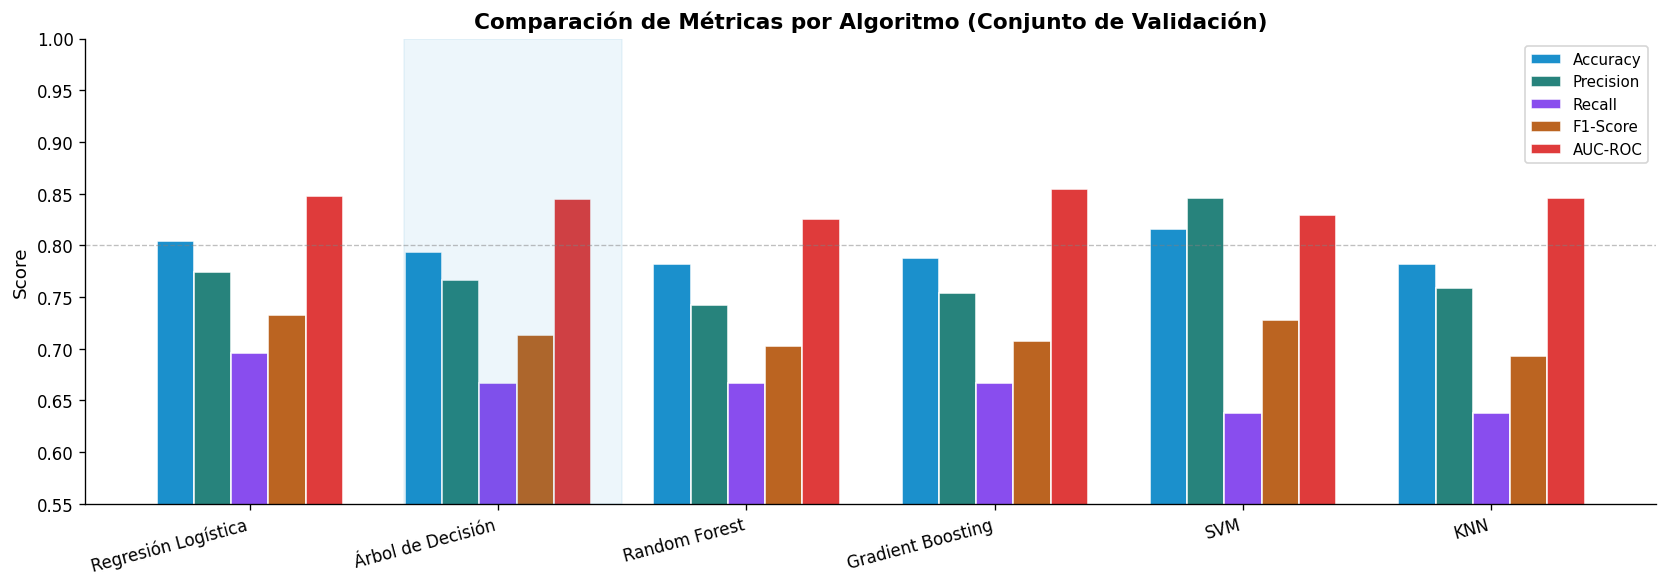

In [ ]:
# ── Gráfico de barras comparativo ────────────────────────────────────
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
nombres   = list(resultados.keys())
x         = np.arange(len(nombres))
ancho     = 0.15

fig, ax = plt.subplots(figsize=(14, 5))

palette = ['#0284C7', '#0F766E', '#7C3AED', '#B45309', '#DC2626', '#334155']
for i, metrica in enumerate(metricas):
    vals = [resultados[n][metrica] for n in nombres]
    bars = ax.bar(x + i * ancho, vals, width=ancho, label=metrica,
                  color=palette[i], alpha=0.9, edgecolor='white')

ax.set_xticks(x + ancho * 2)
ax.set_xticklabels(nombres, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.55, 1.0)
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas por Algoritmo (Conjunto de Validación)',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Marcar el mejor modelo
mejor_idx = list(nombres).index(campeon_nombre)
ax.axvspan(mejor_idx - 0.08, mejor_idx + len(metricas) * ancho + 0.05,
           alpha=0.07, color='#0284C7', label='_nolegend_')

plt.tight_layout()
plt.show()

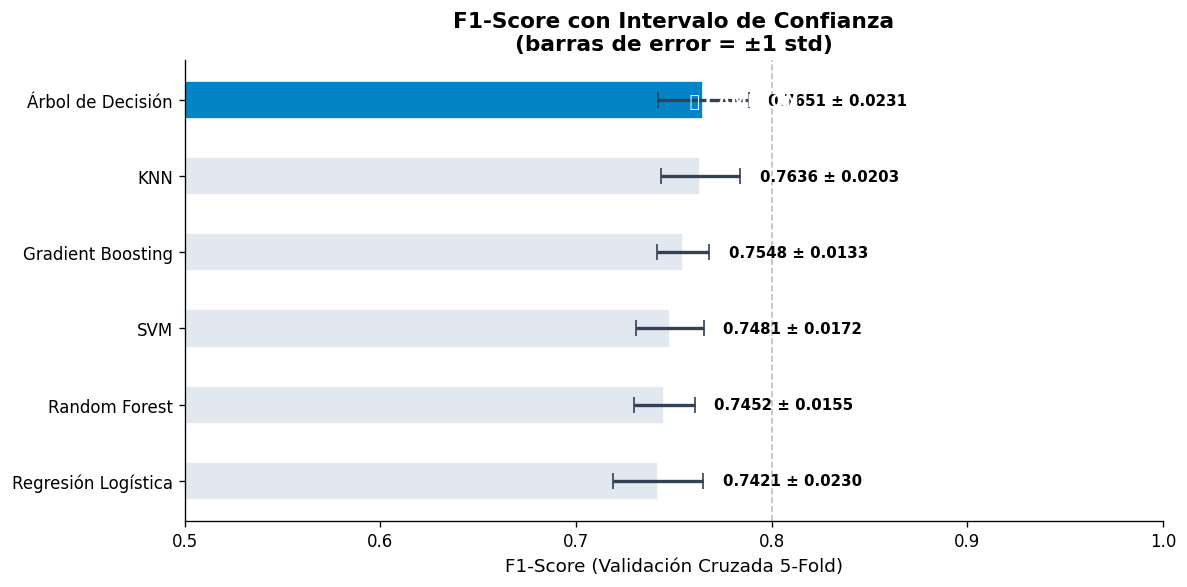

📌 La barra de error muestra estabilidad: std pequeño = modelo consistente.


In [ ]:
# ── Comparación F1-Score con intervalo de confianza (CV) ─────────────
fig, ax = plt.subplots(figsize=(10, 5))

nombres_sorted = df_resultados.sort_values('CV F1 (media)').index.tolist()
medias = [resultados[n]['CV F1 (media)'] for n in nombres_sorted]
stds   = [resultados[n]['CV F1 (std)']   for n in nombres_sorted]

colors = ['#E2E8F0'] * len(nombres_sorted)
colors[-1] = '#0284C7'  # Campeón en azul

bars = ax.barh(nombres_sorted, medias, xerr=stds, color=colors,
               height=0.5, edgecolor='white', capsize=5,
               error_kw={'elinewidth': 2, 'ecolor': '#334155'})

ax.set_xlabel('F1-Score (Validación Cruzada 5-Fold)')
ax.set_title('F1-Score con Intervalo de Confianza\n(barras de error = ±1 std)',
             fontweight='bold')
ax.set_xlim(0.5, 1.0)
ax.axvline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)

for bar, val, std in zip(bars, medias, stds):
    ax.text(val + std + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ± {std:.4f}', va='center', fontsize=9, fontweight='bold')

# Etiqueta campeón
ax.text(medias[-1] - 0.01, len(nombres_sorted) - 1, ' 🏆 CAMPEÓN', va='center',
        color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("📌 La barra de error muestra estabilidad: std pequeño = modelo consistente.")

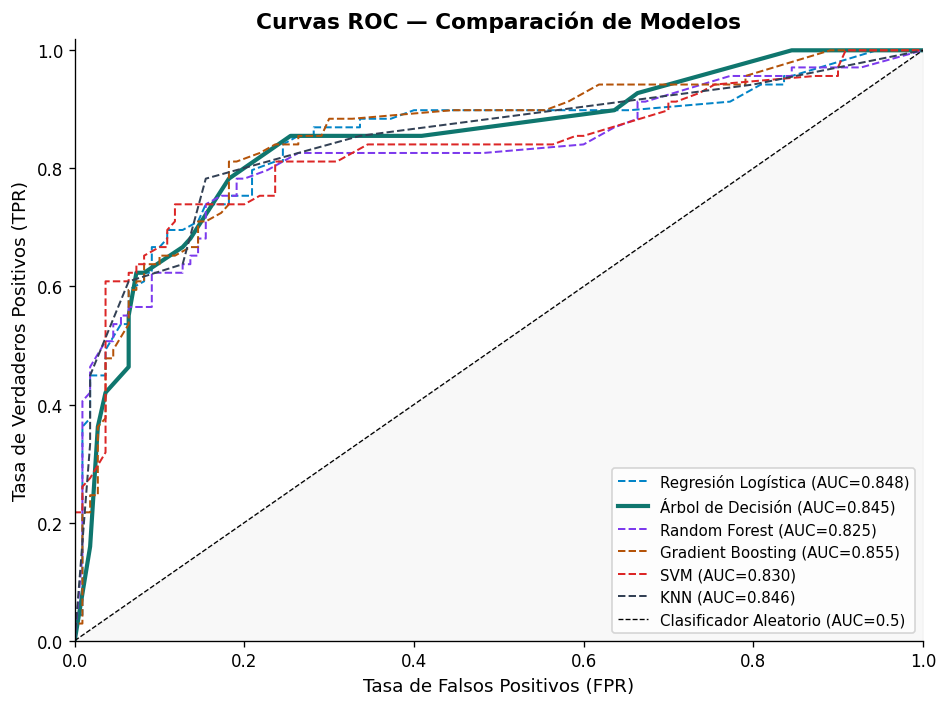

📌 La curva ROC muestra el trade-off entre detectar sobrevivientes (TPR)
   y equivocarse en pasajeros que no sobrevivieron (FPR).
   Un AUC cercano a 1.0 indica excelente capacidad discriminativa.


In [ ]:
# ── Curvas ROC de todos los modelos ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = ['#0284C7', '#0F766E', '#7C3AED', '#B45309', '#DC2626', '#334155']
for (nombre, r), color in zip(resultados.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_val, r['y_pred_prob'])
    auc = r['AUC-ROC']
    lw = 2.5 if nombre == campeon_nombre else 1.2
    ls = '-' if nombre == campeon_nombre else '--'
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})",
            color=color, linewidth=lw, linestyle=ls)

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Clasificador Aleatorio (AUC=0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de Modelos', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

print("📌 La curva ROC muestra el trade-off entre detectar sobrevivientes (TPR)")
print("   y equivocarse en pasajeros que no sobrevivieron (FPR).")
print("   Un AUC cercano a 1.0 indica excelente capacidad discriminativa.")

---
## 🔬 Sección 7 — Análisis Profundo del Modelo Campeón

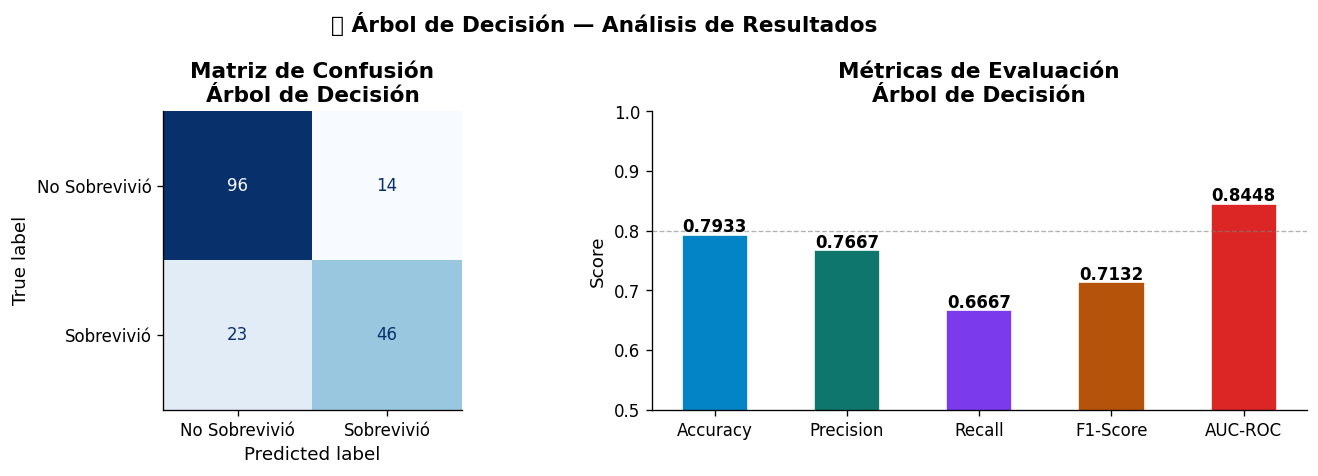


Interpretación de la Matriz de Confusión:
  TP = 46: Predijo SOBREVIVIÓ   y realmente sobrevivió   ✅
  TN = 96: Predijo NO SOBREVIVIÓ y realmente no sobrevivió ✅
  FP = 14: Predijo SOBREVIVIÓ   pero no sobrevivió        ❌ (Falsa Alarma)
  FN = 23: Predijo NO SOBREVIVIÓ pero sí sobrevivió       ❌ (Caso Perdido)


In [ ]:
# ── Matriz de Confusión del campeón ──────────────────────────────────
campeon_res = resultados[campeon_nombre]
y_pred_campeon = campeon_res['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred_campeon)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Sobrevivió', 'Sobrevivió'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión\n{campeon_nombre}', fontweight='bold')

# Métricas individuales
metricas_campeon = {
    'Accuracy':  campeon_res['Accuracy'],
    'Precision': campeon_res['Precision'],
    'Recall':    campeon_res['Recall'],
    'F1-Score':  campeon_res['F1-Score'],
    'AUC-ROC':   campeon_res['AUC-ROC'],
}
colors_m = ['#0284C7', '#0F766E', '#7C3AED', '#B45309', '#DC2626']
bars = axes[1].bar(metricas_campeon.keys(), metricas_campeon.values(),
                   color=colors_m, width=0.5, edgecolor='white')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title(f'Métricas de Evaluación\n{campeon_nombre}', fontweight='bold')
axes[1].set_ylabel('Score')
for bar, val in zip(bars, metricas_campeon.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[1].axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle(f'🏆 {campeon_nombre} — Análisis de Resultados',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Interpretar la matriz
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretación de la Matriz de Confusión:")
print(f"  TP = {tp}: Predijo SOBREVIVIÓ   y realmente sobrevivió   ✅")
print(f"  TN = {tn}: Predijo NO SOBREVIVIÓ y realmente no sobrevivió ✅")
print(f"  FP = {fp}: Predijo SOBREVIVIÓ   pero no sobrevivió        ❌ (Falsa Alarma)")
print(f"  FN = {fn}: Predijo NO SOBREVIVIÓ pero sí sobrevivió       ❌ (Caso Perdido)")

In [ ]:
# ── Reporte de clasificación detallado ────────────────────────────────
print(f"📋 REPORTE COMPLETO — {campeon_nombre}")
print("─" * 55)
print(classification_report(y_val, y_pred_campeon,
                             target_names=['No Sobrevivió', 'Sobrevivió']))
print()
print("Glosario de métricas:")
print("  Precision = De los que predije como positivos, ¿cuántos acerté?")
print("  Recall    = De los positivos reales, ¿cuántos detecté?")
print("  F1-Score  = Media armónica de Precision y Recall")
print("  Support   = Cantidad de ejemplos reales de esa clase")

📋 REPORTE COMPLETO — Árbol de Decisión
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

No Sobrevivió       0.81      0.87      0.84       110
   Sobrevivió       0.77      0.67      0.71        69

     accuracy                           0.79       179
    macro avg       0.79      0.77      0.78       179
 weighted avg       0.79      0.79      0.79       179


Glosario de métricas:
  Precision = De los que predije como positivos, ¿cuántos acerté?
  Recall    = De los positivos reales, ¿cuántos detecté?
  F1-Score  = Media armónica de Precision y Recall
  Support   = Cantidad de ejemplos reales de esa clase


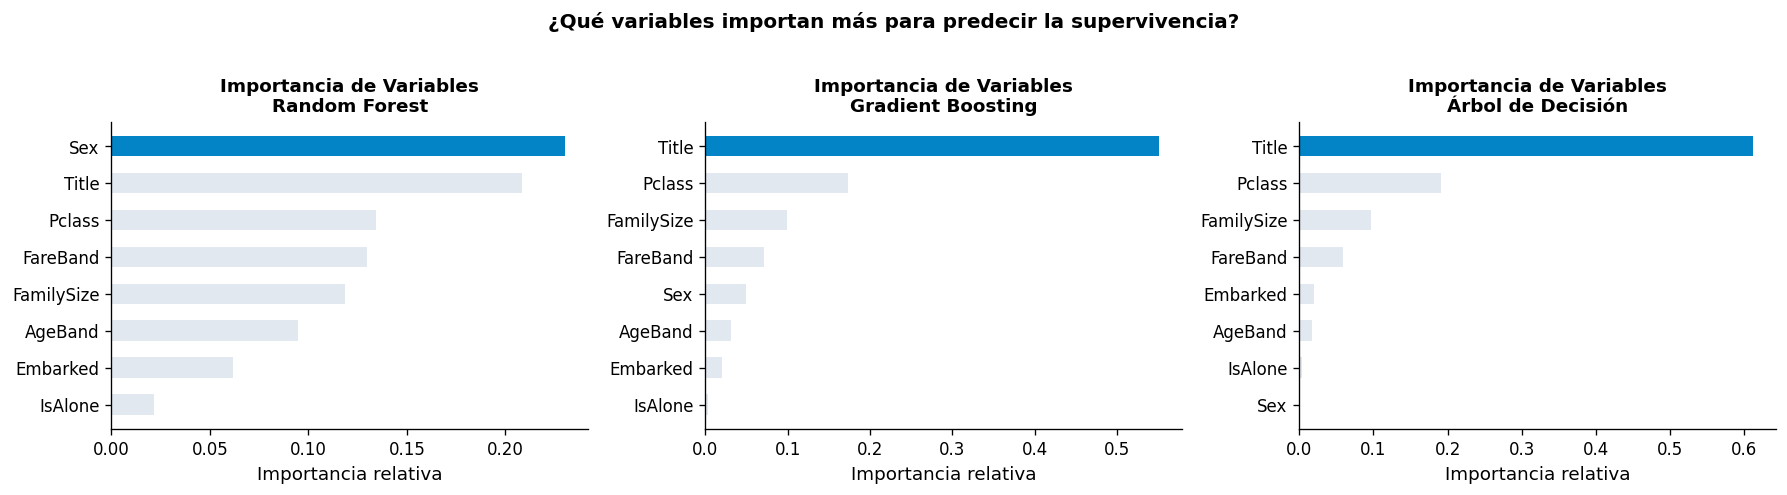

📌 Las variables más importantes suelen ser consistentes entre modelos.
   Title y Sex capturan la política de 'mujeres y niños primero'.


In [ ]:
# ── Importancia de Variables (solo para modelos basados en árboles) ──
modelos_con_importancia = ['Random Forest', 'Gradient Boosting', 'Árbol de Decisión']
modelos_disponibles = [m for m in modelos_con_importancia if m in resultados]

if modelos_disponibles:
    fig, axes = plt.subplots(1, len(modelos_disponibles),
                              figsize=(5 * len(modelos_disponibles), 4))
    if len(modelos_disponibles) == 1:
        axes = [axes]

    for ax, nombre in zip(axes, modelos_disponibles):
        modelo_obj = resultados[nombre]['modelo']
        importancias = modelo_obj.feature_importances_
        sorted_idx = np.argsort(importancias)

        colors_imp = ['#0284C7' if i == sorted_idx[-1] else '#E2E8F0'
                      for i in range(len(importancias))]
        ax.barh(np.array(FEATURES)[sorted_idx], importancias[sorted_idx],
                color=np.array(colors_imp)[sorted_idx], height=0.55)
        ax.set_title(f'Importancia de Variables\n{nombre}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Importancia relativa')

    plt.suptitle('¿Qué variables importan más para predecir la supervivencia?',
                 fontweight='bold', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    print("📌 Las variables más importantes suelen ser consistentes entre modelos.")
    print("   Title y Sex capturan la política de 'mujeres y niños primero'.")

---
## 🌲 Sección 7b — Visualización del Árbol de Decisión

> El Árbol de Decisión es el modelo más interpretable: podemos ver exactamente qué reglas usa para clasificar. Vamos a "leer" el árbol.

In [ ]:
# Mostrar las reglas del árbol de decisión como texto
arbol = resultados['Árbol de Decisión']['modelo']
reglas = export_text(arbol, feature_names=FEATURES, max_depth=3)

print("🌲 ÁRBOL DE DECISIÓN (primeros 3 niveles):")
print("─" * 55)
print(reglas)
print()
print("📌 Cómo leer el árbol:")
print("   'Title <= 1.5' → Si el título es 0 (Mr) o 1 (Mrs)")
print("   'class: 0' → El modelo predice que NO sobrevivió")
print("   'class: 1' → El modelo predice que SÍ sobrevivió")

🌲 ÁRBOL DE DECISIÓN (primeros 3 niveles):
───────────────────────────────────────────────────────
|--- Title <= 0.50
|   |--- Pclass <= 1.50
|   |   |--- FareBand <= 1.00
|   |   |   |--- class: 0
|   |   |--- FareBand >  1.00
|   |   |   |--- FareBand <= 2.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- FareBand >  2.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- Pclass >  1.50
|   |   |--- FareBand <= 0.50
|   |   |   |--- AgeBand <= 2.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- AgeBand >  2.50
|   |   |   |   |--- class: 0
|   |   |--- FareBand >  0.50
|   |   |   |--- IsAlone <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- IsAlone >  0.50
|   |   |   |   |--- truncated branch of depth 2
|--- Title >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Title <= 3.50
|   |   |   |--- FareBand <= 2.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- FareBand >  2.50
|   |   |   |   |--- trunca

---
## 🎯 Sección 8 — Predicciones Finales con el Modelo Campeón

Ahora usaremos el modelo campeón para predecir la supervivencia de los 418 pasajeros del `test.csv`, que **nunca fueron vistos** durante el entrenamiento o la validación.

> Esto simula el escenario real de producción: el modelo recibe datos nuevos y genera predicciones.

In [ ]:
# ── Generar predicciones finales ─────────────────────────────────────
campeon_modelo = resultados[campeon_nombre]['modelo']

# Seleccionar datos correctos (con o sin escalado)
if resultados[campeon_nombre]['usa_escalado']:
    X_pred = X_test_scaled
else:
    X_pred = X_test_final.values

# Predecir
predicciones     = campeon_modelo.predict(X_pred)
prob_supervivir  = campeon_modelo.predict_proba(X_pred)[:, 1]

# Crear DataFrame de resultados
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived':    predicciones,
    'Probabilidad': prob_supervivir.round(3)
})

print(f"🏆 Predicciones generadas con: {campeon_nombre}")
print(f"   Total predicciones: {len(submission)}")
print(f"   Predichos que sobreviven:    {predicciones.sum()} ({predicciones.mean()*100:.1f}%)")
print(f"   Predichos que no sobreviven: {(1-predicciones).sum()} ({(1-predicciones).mean()*100:.1f}%)")
print()
print("Primeras 10 predicciones:")
submission.head(10)

🏆 Predicciones generadas con: Árbol de Decisión
   Total predicciones: 418
   Predichos que sobreviven:    153 (36.6%)
   Predichos que no sobreviven: 265 (63.4%)

Primeras 10 predicciones:


,PassengerId,Survived,Probabilidad
0,892,0,0.154
1,893,0,0.419
2,894,0,0.138
3,895,0,0.138
4,896,0,0.419
5,897,0,0.138
6,898,1,0.864
7,899,0,0.047
8,900,1,0.864
9,901,0,0.047


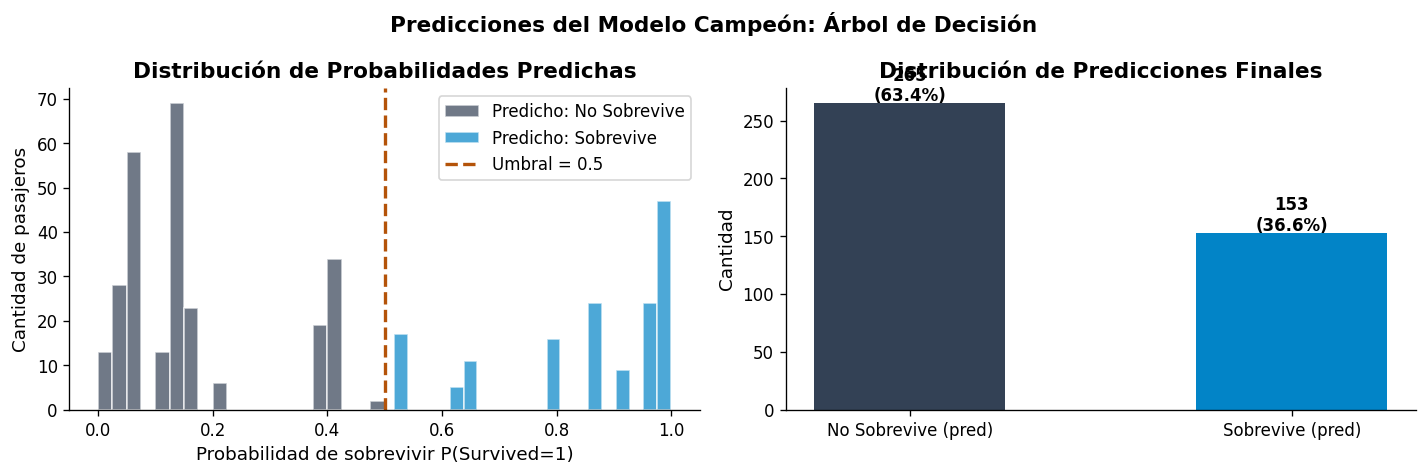

In [ ]:
# ── Visualizar distribución de probabilidades predichas ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de probabilidades
axes[0].hist(prob_supervivir[predicciones == 0], bins=20, alpha=0.7,
             color='#334155', label='Predicho: No Sobrevive', edgecolor='white')
axes[0].hist(prob_supervivir[predicciones == 1], bins=20, alpha=0.7,
             color='#0284C7', label='Predicho: Sobrevive', edgecolor='white')
axes[0].axvline(0.5, color='#B45309', linestyle='--', linewidth=2, label='Umbral = 0.5')
axes[0].set_xlabel('Probabilidad de sobrevivir P(Survived=1)')
axes[0].set_ylabel('Cantidad de pasajeros')
axes[0].set_title('Distribución de Probabilidades Predichas', fontweight='bold')
axes[0].legend()

# Distribución de predicciones
counts_pred = pd.Series(predicciones).value_counts()
colors_pred = ['#334155', '#0284C7']
bars = axes[1].bar(['No Sobrevive (pred)', 'Sobrevive (pred)'],
                   [counts_pred.get(0, 0), counts_pred.get(1, 0)],
                   color=colors_pred, width=0.5)
axes[1].set_title('Distribución de Predicciones Finales', fontweight='bold')
axes[1].set_ylabel('Cantidad')
for bar, val in zip(bars, [counts_pred.get(0, 0), counts_pred.get(1, 0)]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val}\n({val/len(predicciones)*100:.1f}%)', ha='center', fontweight='bold')

plt.suptitle(f'Predicciones del Modelo Campeón: {campeon_nombre}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Guardar predicciones finales ─────────────────────────────────────
submission_final = submission[['PassengerId', 'Survived']]
submission_final.to_csv('submission.csv', index=False)

print("✅ Archivo 'submission.csv' guardado con éxito.")
print()
print("Formato del archivo:")
print(submission_final.head())

✅ Archivo 'submission.csv' guardado con éxito.

Formato del archivo:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


---
## 📝 Sección 9 — Resumen, Conclusiones y Próximos Pasos

### ✅ Lo que aprendimos en este ejercicio:

| Paso | Qué hicimos | Por qué es importante |
|------|-------------|----------------------|
| **EDA** | Exploramos distribuciones y correlaciones | Entender los datos antes de modelar |
| **Limpieza** | Imputamos nulos con mediana/moda | Los modelos no toleran valores nulos |
| **Feature Engineering** | Creamos `Title`, `FamilySize`, `AgeBand`, `FareBand` | Las nuevas variables capturan patrones no evidentes |
| **Encoding** | Convertimos texto a números | Los algoritmos solo entienden números |
| **Train/Val Split** | Separamos el 20% para validación | Necesitamos datos no vistos para evaluar honestamente |
| **Escalado** | Aplicamos `StandardScaler` a ciertos modelos | SVM, LR y KNN son sensibles a la escala |
| **Comparación** | Entrenamos 6 algoritmos con los mismos datos | No hay un solo algoritmo perfecto para todos los casos |
| **Métricas** | Accuracy, Precision, Recall, F1, AUC, CV | Cada métrica mide algo diferente del desempeño |
| **Predicción** | Usamos el campeón sobre el test final | Simulación de escenario real de producción |

---

### 🚀 Próximos pasos para seguir mejorando:

1. **Tuning de Hiperparámetros:** `GridSearchCV` o `RandomizedSearchCV` sobre el modelo campeón
2. **Más Feature Engineering:** Extraer el número de camarote del campo `Cabin`, interacciones entre variables
3. **Stacking/Voting:** Combinar las predicciones de múltiples modelos
4. **Análisis de errores:** ¿En qué pasajeros se equivoca el modelo? ¿Hay un patrón?
5. **Threshold tuning:** Ajustar el umbral de 0.5 según la métrica que nos importe más

In [ ]:
# ── Panel final de resultados ─────────────────────────────────────────
print("=" * 65)
print("  RESUMEN FINAL — COMPARACIÓN DE MODELOS")
print("=" * 65)
print(f"  {'Modelo':<24} {'Accuracy':>9} {'F1-Score':>9} {'CV F1':>10} {'AUC':>8}")
print("─" * 65)

ranking = sorted(resultados.items(),
                 key=lambda x: x[1]['CV F1 (media)'], reverse=True)

for i, (nombre, r) in enumerate(ranking):
    trophy = "🏆" if i == 0 else f"  {i+1}."
    print(f"  {trophy} {nombre:<22} {r['Accuracy']:>9.4f} {r['F1-Score']:>9.4f} "
          f"{r['CV F1 (media)']:>10.4f} {r['AUC-ROC']:>8.4f}")

print("─" * 65)
print(f"\n  Modelo Campeón seleccionado: {campeon_nombre}")
print(f"  Predicciones generadas para {len(submission)} pasajeros del test.csv")
print(f"  Archivo de salida: submission.csv")
print()
print("  💡 Recuerda: el mejor modelo en validación no siempre es el mejor")
print("     en producción. El proceso es iterativo. ¡Sigue experimentando!")

  RESUMEN FINAL — COMPARACIÓN DE MODELOS
  Modelo                    Accuracy  F1-Score      CV F1      AUC
─────────────────────────────────────────────────────────────────
  🏆 Árbol de Decisión         0.7933    0.7132     0.7651   0.8448
    2. KNN                       0.7821    0.6929     0.7636   0.8458
    3. Gradient Boosting         0.7877    0.7077     0.7548   0.8547
    4. SVM                       0.8156    0.7273     0.7481   0.8296
    5. Random Forest             0.7821    0.7023     0.7452   0.8254
    6. Regresión Logística       0.8045    0.7328     0.7421   0.8481
─────────────────────────────────────────────────────────────────

  Modelo Campeón seleccionado: Árbol de Decisión
  Predicciones generadas para 418 pasajeros del test.csv
  Archivo de salida: submission.csv

  💡 Recuerda: el mejor modelo en validación no siempre es el mejor
     en producción. El proceso es iterativo. ¡Sigue experimentando!


---
## ✏️ Sección 10 — Ejercicios para Practicar

> **Instrucciones:** Completa los siguientes ejercicios modificando el código de este notebook.

---

### Ejercicio 1 — Cambiar el Modelo Base
Modifica el `max_depth` del Árbol de Decisión a valores de 3, 7 y 10.  
¿Qué pasa con el F1-Score en validación? ¿Se produce overfitting?

```python
# Tu código aquí
arbol_modificado = DecisionTreeClassifier(max_depth=???, random_state=RANDOM_STATE)
# ...
```

---

### Ejercicio 2 — Nueva Feature
Crea una variable `HasCabin` que sea 1 si el pasajero tenía cabina asignada y 0 si no.  
Agrégala al pipeline y observa si mejora las métricas.

```python
# Tu código aquí: usa el DataFrame original antes de eliminar 'Cabin'
train_clean['HasCabin'] = (train['Cabin'].notna()).astype(int)
# ...
```

---

### Ejercicio 3 — Cambiar el Umbral de Decisión
Por defecto clasificamos como "sobrevive" cuando P(Survived=1) > 0.5.  
¿Qué pasa con Precision y Recall si cambiamos el umbral a 0.4 o 0.6?

```python
# Tu código aquí
umbral = 0.40
y_pred_nuevo = (campeon_res['y_pred_prob'] >= umbral).astype(int)
print(classification_report(y_val, y_pred_nuevo, target_names=['No Sobrevivió', 'Sobrevivió']))
```

---

### Ejercicio 4 — Agregar Gradient Boosting con Hiperparámetros
Entrena un nuevo `GradientBoostingClassifier` con `n_estimators=200` y `learning_rate=0.05`.  
¿Mejora respecto al que ya entrenamos?

In [ ]:
# ── Espacio de trabajo para los ejercicios ───────────────────────────
# Escribe tu código aquí 👇

